# Bet Simulator
In questo notebook è contenuto il bet silumator del progetto. L'obiettivo è comprendere, utilizzando i vari modelli e impostando una metodologia di scommesse, quanto sarebbe il guadagno ottenuto da ciascun modello (compresa la baseline casuale).

## Metodologia di scommessa
L'approcio che utilizziamo è semplice, scommettere 10 euro su ogni partita, sulla classe consigliata dal nostro modello,

## Modelli

Adesso verifichiamo qual è il guadagno dei singoli modelli

## Importazione dei dataset e merge
Per prima cosa facciamo la merge tra i due dataset (scommesse e partite) importati, di modo da avere tutti i dati necessari.  

In [59]:
import pandas as pd
import difflib
import numpy as np

class Odds:

    __odds_dataset: pd.DataFrame
    __match_dataset: pd.DataFrame
    __merged_dataset: pd.DataFrame

    def __merge_dataset(self) -> None:

        # Normalizzazione delle date
        self.__match_dataset['Match_Date_Temp'] = pd.to_datetime(
            self.__match_dataset['Date'], 
            errors='coerce' 
        ).dt.date

        self.__odds_dataset['Odds_Date_Temp'] = pd.to_datetime(
            self.__odds_dataset['matchDate'], 
            format="%d-%m-%y %H:%M", 
            errors='coerce' 
        ).dt.date

        # Risoluzione dei nomi delle squadre
        self.__match_dataset = self.__match_dataset.dropna(subset=['Match_Date_Temp'])
        self.__odds_dataset = self.__odds_dataset.dropna(subset=['Odds_Date_Temp'])
        match_teams = pd.concat([self.__match_dataset['HomeTeam'], self.__match_dataset['AwayTeam']]).unique()
        odds_teams = pd.concat([self.__odds_dataset['homeTeam'], self.__odds_dataset['awayTeam']]).unique()

        team_mapping = {}
        for team in odds_teams:
            matches = difflib.get_close_matches(team, match_teams, n=1, cutoff=0.5)
            team_mapping[team] = matches[0] if matches else team

        self.__odds_dataset['homeTeam_Norm'] = self.__odds_dataset['homeTeam'].map(team_mapping)
        self.__odds_dataset['awayTeam_Norm'] = self.__odds_dataset['awayTeam'].map(team_mapping)

        # Affiancamento dei due dataset
        self.__merged_dataset = pd.merge(
            left=self.__match_dataset,
            right=self.__odds_dataset,
            left_on=['Match_Date_Temp', 'HomeTeam', 'AwayTeam'],
            right_on=['Odds_Date_Temp', 'homeTeam_Norm', 'awayTeam_Norm'],
            how='inner' 
        )

        # Pulizia delle colonne temporanee create per il merge
        col_rimuovere_match = ['Match_Date_Temp']
        col_rimuovere_odds = ['Odds_Date_Temp', 'homeTeam_Norm', 'awayTeam_Norm']
        
        # Le puliamo sia dai dataset originali che dal dataset finale
        self.__match_dataset.drop(columns=col_rimuovere_match, inplace=True, errors='ignore')
        self.__odds_dataset.drop(columns=col_rimuovere_odds, inplace=True, errors='ignore')
        self.__merged_dataset.drop(columns=col_rimuovere_match + col_rimuovere_odds, inplace=True, errors='ignore')

    def __dataset_feature(self):
        
        self.__merged_dataset["WinStreak"] = self.__merged_dataset["Home_WinStreak"] - self.__merged_dataset["Away_WinStreak"]
        self.__merged_dataset["Z_Goals_Season"] = self.__merged_dataset["Z_Home_Goals_Season"] - self.__merged_dataset["Z_Away_Goals_Season"]
        self.__merged_dataset["Z_Wins_Season"] = self.__merged_dataset["Z_Home_Wins_Season"] - self.__merged_dataset["Z_Away_Wins_Season"]
        self.__merged_dataset["GoalOnShotRatio"] = self.__merged_dataset["GoalOnShotRatioHome"] - self.__merged_dataset["GoalOnShotRatioAway"]
        self.__merged_dataset["PointToMatchRatio"] = self.__merged_dataset["PointToMatchRatioHome"] - self.__merged_dataset["PointToMatchRatioAway"]
        self.__merged_dataset['Abs_Points_Difference'] = (self.__merged_dataset['Home_Current_Points'] - self.__merged_dataset['Away_Current_Points']).abs()
        self.__merged_dataset["Elo"] = self.__merged_dataset["HomeElo"] - self.__merged_dataset["AwayElo"]
        self.__merged_dataset["Abs_Value_Difference"] = (self.__merged_dataset["HomeValue"] - self.__merged_dataset["AwayValue"]).abs()
        self.__merged_dataset["Value"] = self.__merged_dataset["HomeValue"] - self.__merged_dataset["AwayValue"]

        # Variabile booleana che indica un match equilibrato sulla carta, ossia  
        # se le due squadre hanno meno di 3 punti di distacco 
        self.__merged_dataset['Is_Points_Balanced'] = (self.__merged_dataset['Abs_Points_Difference'] <= 3).astype(int)

        # Elimino le feature inutilizzate
        self.__merged_dataset = self.__merged_dataset.drop(columns=["Home_WinStreak", "Away_WinStreak", "Z_Home_Goals_Season", "Z_Away_Goals_Season", "Z_Home_Wins_Season", "Z_Away_Wins_Season", "GoalOnShotRatioHome", "GoalOnShotRatioAway", "PointToMatchRatioHome", "PointToMatchRatioAway", "HomeElo", "AwayElo", "HomeValue", "AwayValue"])

    def __init__(
            self,
            odds_dataframe_path: str,
            match_dataframe_path
    ) -> None:

        # Importazione e rimozione delle rows vuote 
        self.__odds_dataset = pd.read_csv(odds_dataframe_path)
        self.__match_dataset = pd.read_csv(match_dataframe_path)
        self.__odds_dataset = self.__odds_dataset.dropna()

        # Merge dei due dataset
        self.__merge_dataset()
        self.__dataset_feature()
    
    def backtest_distribution(self, season: int, n_simulations: int = 1000, seed: int | None = None) -> np.ndarray:
        """
        Ripete il backtest casuale n_simulations volte e mostra la distribuzione
        del guadagno/perdita ottenuto.
        Args:
            season: stagione su cui testare il modello (2024, 2025)
            n_simulations: numero di simulazioni da eseguire
            seed: seed opzionale per la riproducibilità
        Returns:
            array dei guadagni ottenuti in ogni simulazione
        """
        import matplotlib.pyplot as plt

        rng = np.random.default_rng(seed)
        selected_df = self.__merged_dataset[self.__merged_dataset["Season_x"] == f"{season}-{season+1}"]
        n = len(selected_df)
        if n == 0:
            return np.array([])

        result_map = {0: 'H', 1: 'D', 2: 'A'}
        odds_matrix = selected_df[['H', 'D', 'A']].to_numpy(dtype=float)
        results = selected_df['FTR'].to_numpy()
        cash_in = 10 * n

        predictions = rng.integers(0, 3, size=(n_simulations, n))
        pred_labels = np.vectorize(result_map.get)(predictions)
        correct = pred_labels == results[np.newaxis, :]

        row_idx = np.arange(n)
        selected_odds = odds_matrix[row_idx, predictions]

        earn_per_sim = np.sum(np.where(correct, 10 * selected_odds, 0.0), axis=1)
        profit = earn_per_sim - cash_in

        mean_profit = profit.mean()
        fig, ax = plt.subplots(figsize=(9, 5))
        ax.hist(profit, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
        ax.axvline(0, color='black', linestyle='--', linewidth=1, label='Break-even')
        ax.axvline(mean_profit, color='red', linestyle='-', linewidth=1.5, label=f'Media: {mean_profit:.2f}')
        ax.set_title(f'Distribuzione del guadagno - Stagione {season}-{season+1} ({n_simulations} simulazioni)')
        ax.set_xlabel('Guadagno netto')
        ax.set_ylabel('Frequenza')
        ax.legend()
        plt.tight_layout()
        plt.savefig('gauss_random.png', dpi=300, bbox_inches='tight')
        plt.show()

        return profit

    def backtest_with_model(
        self,
        season: int,
        model_path: str,
        baseline_features: list[str],
        draw_threshold: float = 0.33,
        scaler: str | None = None
    ) -> float:
        """
        Backtest che utilizza un modello allenato (.joblib), applicando una soglia
        sulla probabilità di pareggio: se P(pareggio) >= draw_threshold si predice X,
        altrimenti si sceglie tra 1 e 2 in base alla probabilità maggiore.
        Args:
            season: stagione su cui testare il modello (2024, 2025)
            model_path: percorso del file .joblib con il modello allenato
            baseline_features: feature da passare al modello (le stesse usate in training)
            draw_threshold: soglia sulla probabilità di pareggio
        Returns:
            guadagno netto ottenuto
        """
        import joblib

        loaded = joblib.load(model_path)
        stake = 1

        if isinstance(loaded, (tuple, list)):
            model, scaler = loaded[0], loaded[1]
        
        elif isinstance(loaded, dict):
            model, scaler = loaded.get('model'), loaded.get('scaler')
            baseline_features = loaded.get('features', baseline_features)
        
        else:
            model = loaded

        selected_df = self.__merged_dataset[self.__merged_dataset["Season_x"] == f"{season}-{season+1}"]
        # selected_df = self.__merged_dataset
        n = len(selected_df)
        
        if n == 0:
            return 0.0

        result_map = {0: 'H', 1: 'D', 2: 'A'}
        X = selected_df[baseline_features]
        X_scaled = scaler.transform(X) if scaler is not None else X

        probs = model.predict_proba(X_scaled)
        predictions = np.where(
            probs[:, 1] >= draw_threshold,
            1,
            np.where(probs[:, 0] > probs[:, 2], 0, 2)
        )
        pred_labels = np.vectorize(result_map.get)(predictions)

        odds_matrix = selected_df[['H', 'D', 'A']].to_numpy(dtype=float)
        results = selected_df['FTR'].to_numpy()

        correct = pred_labels == results
        selected_odds = odds_matrix[np.arange(n), predictions]

        earn = np.sum(np.where(correct, stake * selected_odds, 0.0))
        cash_in = stake * n
        return float(earn - cash_in)

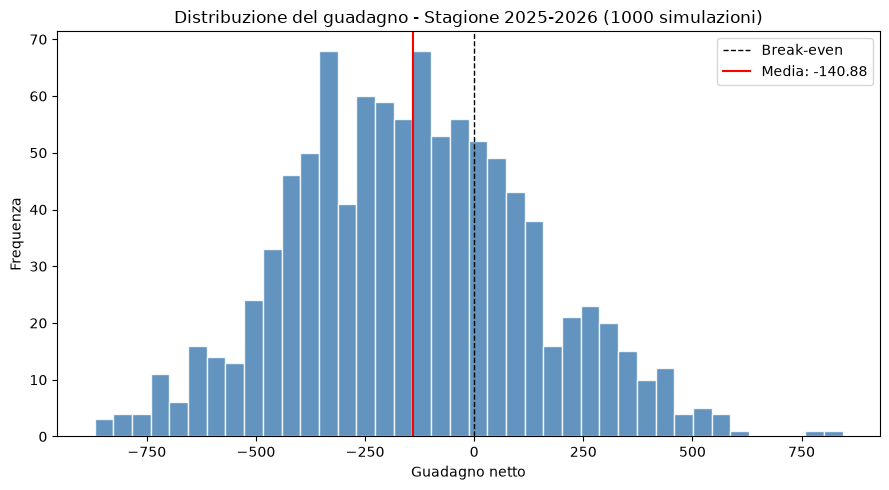

array([-9.570e+01,  2.600e+00,  2.831e+02, -2.632e+02,  7.580e+01,
       -1.278e+02,  4.122e+02, -2.185e+02, -4.298e+02,  6.190e+01,
        1.496e+02, -3.388e+02,  1.689e+02, -2.756e+02,  6.000e-01,
       -1.461e+02, -3.952e+02, -1.255e+02, -4.265e+02, -1.160e+02,
        2.735e+02,  6.440e+01,  4.559e+02,  1.474e+02, -1.326e+02,
        2.970e+01, -5.390e+01,  5.050e+01, -1.842e+02, -1.182e+02,
       -2.100e+01,  1.713e+02, -6.139e+02,  3.145e+02,  4.810e+01,
       -3.260e+02, -2.218e+02,  3.290e+01, -4.874e+02, -2.879e+02,
       -6.790e+01, -3.258e+02, -4.000e+02,  1.301e+02, -3.224e+02,
       -3.878e+02,  3.840e+02,  4.315e+02, -2.441e+02,  2.062e+02,
       -2.415e+02, -4.350e+01, -8.550e+01, -5.031e+02,  1.818e+02,
       -5.490e+01, -3.410e+01,  7.200e+00, -4.025e+02, -9.110e+01,
       -6.940e+01, -1.815e+02, -3.270e+02, -5.781e+02,  9.030e+01,
       -2.000e+00, -2.330e+02,  2.380e+01,  1.169e+02, -1.964e+02,
       -7.740e+01, -7.547e+02,  3.931e+02,  2.251e+02, -6.255e

In [60]:
# Dopo aver instanziato la classe e fatto il merge:
gestore_quote = Odds("static/odds/odds.csv", "static/da-result/result.csv")

gestore_quote.backtest_distribution(2025)

### Regressione lineare
In questo caso scommetto sulla regressione lineare. Consideriamo che la soglia dei pareggi è impostata al 27%.

In [ ]:
gestore_quote.backtest_with_model(2025, "static/models/linear_model.joblib", ["WinStreak", "GoalOnShotRatio", "Elo", "HomeAdvantage", "Z_Goals_Season", "Abs_Points_Difference"], 0.27)

0.3100000000000023

## Random Forest
In questo caso scommetto con il modello di random forest.

In [62]:
gestore_quote.backtest_with_model(2025, "static/models/random_forest_model.joblib", ["Value", "Z_Wins_Season", "Abs_Value_Difference"], 0.29)

26.980000000000018